# Budowa finalnego zbioru danych - preprocessing i feature engineering

## Konfiguracja i importowanie bibliotek

In [7]:
import sys
from pathlib import Path
import pandas as pd
import xarray as xr

# Dodanie katalogu głównego do sys.path
root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from src.config import (
    RAW_DATA_DIR, PROCESSED_DATA_DIR,
    DEM_RASTER_PATH, LAND_COVER_PATH, ERA5_NETCDF_PATH,
    BALICE_PATH, OBSERWATORIUM_PATH,
    DATASET_FILE, DATASET_2022_PATH, KRAKOW_BBOX
)
from src.utils_geo import sample_dem, compute_urban_fraction
from src.utils_time import localize_to_utc, add_cyclic_temporal_features
from src.climatology import add_guminski_seasons_harmonic

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Środowisko i moduły załadowane pomyślnie.")

Środowisko i moduły załadowane pomyślnie.


## Przetwarzanie i łączenie danych ze stacji IMGW

In [ ]:
metadata_imgw = pd.DataFrame([
    {
        'station': 'Krakow-Balice',
        'lat': 50.0777,
        'lon': 19.7848,
        'file_path': BALICE_PATH
    },
    {
        'station': 'Krakow-Obserwatorium',
        'lat': 50.0614,
        'lon': 19.9594,
        'file_path': OBSERWATORIUM_PATH
    }
])

#print("Pobieranie wysokości DEM i wskaźnika urbanizacji dla stacji IMGW...")
metadata_imgw['altitude'] = sample_dem(DEM_RASTER_PATH, metadata_imgw['lat'].values, metadata_imgw['lon'].values)
metadata_imgw['urban_fraction_500m'] = compute_urban_fraction(LAND_COVER_PATH, metadata_imgw['lat'].values, metadata_imgw['lon'].values)

# 2. Wczytanie pomiarów i konwersja czasu do UTC
station_dfs = []
for _, meta in metadata_imgw.iterrows():
    df_raw = pd.read_csv(meta['file_path'])
    dt_local = pd.to_datetime(
        df_raw['year'].astype(str) + '-' +
        df_raw['month'].astype(str).str.zfill(2) + '-' +
        df_raw['day'].astype(str).str.zfill(2) + ' ' +
        df_raw['hour'].astype(str).str.zfill(2) + ':00:00'
    )
    df_raw['timestamp'] = localize_to_utc(dt_local)
    df_raw['station'] = meta['station']
    df_raw['lat'] = meta['lat']
    df_raw['lon'] = meta['lon']
    df_raw['altitude'] = meta['altitude']
    df_raw['urban_fraction_500m'] = meta['urban_fraction_500m']
    df_raw.rename(columns={'temp': 'temp_ground'}, inplace=True)
    
    clean = df_raw[['timestamp', 'station', 'lat', 'lon', 'altitude', 'urban_fraction_500m', 'temp_ground']].dropna()
    station_dfs.append(clean)

df_imgw = pd.concat(station_dfs, ignore_index=True)

# 3. Dołączenie temperatury ERA5-Land
ds = xr.open_dataset(ERA5_NETCDF_PATH)
time_coord = 'valid_time' if 'valid_time' in ds.coords else 'time'

era_series = []
for _, r in metadata_imgw.iterrows():
    pt = ds['t2m'].sel(latitude=r['lat'], longitude=r['lon'], method='nearest').to_dataframe().reset_index()
    pt['temp_era5'] = pt['t2m'] - 273.15
    pt['timestamp'] = pd.to_datetime(pt[time_coord])
    pt['station'] = r['station']
    era_series.append(pt[['timestamp', 'station', 'temp_era5']])

df_era = pd.concat(era_series, ignore_index=True)
df_imgw_merged = pd.merge(df_imgw, df_era, on=['timestamp', 'station'], how='inner')
df_imgw_final = add_cyclic_temporal_features(df_imgw_merged)
df_imgw_final['data_source'] = 'imgw'

print(f"Zbiór IMGW przetworzony: {len(df_imgw_final):,} wierszy.")

Pobieranie wysokości DEM i wskaźnika urbanizacji dla stacji IMGW...
Zbiór IMGW przetworzony: 256,392 wierszy.


## Przetwarzanie i łączenie danych z miejskich sensorów LCS

In [3]:
from pyproj import Transformer
from scipy.spatial import cKDTree

excel_path = RAW_DATA_DIR / "lcs" / "lokalizacja_nazwy_miast_LCS.xlsx"
parquet_path = RAW_DATA_DIR / "lcs" / "dane_z_lokalizacja_godzinne.parquet"

# 1. Metadane stacji LCS
xl = pd.ExcelFile(excel_path)
meta_dfs = [pd.read_excel(excel_path, sheet_name=s) for s in ['KRK', 'ALL_sensors'] if s in xl.sheet_names]
stations_df = pd.concat(meta_dfs, ignore_index=True).dropna(subset=['X', 'Y', 'Localization'])
stations_df.rename(columns={'Localization': 'station'}, inplace=True)
stations_df = stations_df.drop_duplicates(subset=['station']).copy()

# Transformacja UTM 34N -> WGS84
tr_utm = Transformer.from_crs("EPSG:32634", "EPSG:4326", always_xy=True)
stations_df['lon'], stations_df['lat'] = tr_utm.transform(stations_df['X'].values, stations_df['Y'].values)

stations_df = stations_df[
    (stations_df['lon'] >= KRAKOW_BBOX['west']) & (stations_df['lon'] <= KRAKOW_BBOX['east']) &
    (stations_df['lat'] >= KRAKOW_BBOX['south']) & (stations_df['lat'] <= KRAKOW_BBOX['north'])
].copy()

# Próbkowanie cech przestrzennych
stations_df['altitude'] = sample_dem(DEM_RASTER_PATH, stations_df['lat'].values, stations_df['lon'].values)
stations_df['urban_fraction_500m'] = compute_urban_fraction(LAND_COVER_PATH, stations_df['lat'].values, stations_df['lon'].values)
stations_df = stations_df.dropna(subset=['altitude', 'urban_fraction_500m'])
stations_df = stations_df[stations_df['altitude'] > 0].reset_index(drop=True)

# 2. Łączenie pomiarów sensorów za pomocą KDTree (promień 100 m)
df_lcs_raw = pd.read_parquet(parquet_path)
unique_pq = df_lcs_raw[['X', 'Y']].drop_duplicates().copy().reset_index(drop=True)

tree = cKDTree(stations_df[['X', 'Y']].values)
dists, indices = tree.query(unique_pq[['X', 'Y']].values)
unique_pq['station_idx'] = indices
unique_pq['dist_m'] = dists

valid_pq = unique_pq[unique_pq['dist_m'] <= 100.0].copy()
for col in ['station', 'lat', 'lon', 'altitude', 'urban_fraction_500m']:
    valid_pq[col] = stations_df.iloc[valid_pq['station_idx']][col].values

df_lcs = pd.merge(df_lcs_raw, valid_pq.drop(columns=['station_idx']), on=['X', 'Y'], how='inner')
dt_lcs_local = pd.to_datetime(df_lcs['date'].astype(str) + ' ' + df_lcs['hour'].astype(str) + ':00:00')
df_lcs['timestamp'] = localize_to_utc(dt_lcs_local)
df_lcs.dropna(subset=['timestamp'], inplace=True)
df_lcs.rename(columns={'temperature_2m': 'temp_ground'}, inplace=True)

# 3. Dołączenie temperatur ERA5-Land
era5_lcs_pts = []
for _, r in stations_df[['station', 'lat', 'lon']].drop_duplicates().iterrows():
    pt = ds['t2m'].sel(latitude=r['lat'], longitude=r['lon'], method='nearest').to_dataframe().reset_index()
    pt['temp_era5'] = pt['t2m'] - 273.15
    pt['timestamp'] = pd.to_datetime(pt[time_coord])
    pt['station'] = r['station']
    era5_lcs_pts.append(pt[['timestamp', 'station', 'temp_era5']])

df_era_lcs = pd.concat(era5_lcs_pts, ignore_index=True)
df_lcs_merged = pd.merge(df_lcs, df_era_lcs, on=['timestamp', 'station'], how='inner')
df_lcs_final = add_cyclic_temporal_features(df_lcs_merged)
df_lcs_final['data_source'] = 'lcs'

print(f"Zbiór LCS przetworzony: {len(df_lcs_final):,} wierszy.")

Zbiór LCS przetworzony: 113,854 wierszy.


## Scalenie danych w finalny zbiór

In [4]:
print(df_imgw_final.head())

            timestamp        station      lat      lon  altitude  \
0 2000-01-01 00:00:00  Krakow-Balice  50.0777  19.7848     238.0   
1 2000-01-01 01:00:00  Krakow-Balice  50.0777  19.7848     238.0   
2 2000-01-01 02:00:00  Krakow-Balice  50.0777  19.7848     238.0   
3 2000-01-01 03:00:00  Krakow-Balice  50.0777  19.7848     238.0   
4 2000-01-01 04:00:00  Krakow-Balice  50.0777  19.7848     238.0   

   urban_fraction_500m  temp_ground  temp_era5  sin_hour  cos_hour   sin_doy  \
0               0.2566        -12.0  -8.532562  0.000000  1.000000  0.017202   
1               0.2566        -12.5  -8.527802  0.258819  0.965926  0.017202   
2               0.2566        -12.0  -8.966553  0.500000  0.866025  0.017202   
3               0.2566        -11.0  -8.621613  0.707107  0.707107  0.017202   
4               0.2566         -9.6  -8.467133  0.866025  0.500000  0.017202   

    cos_doy data_source  
0  0.999852        imgw  
1  0.999852        imgw  
2  0.999852        imgw  
3  0.9

In [5]:
print(df_lcs_final.head())

    PM25   yh  hour  temp_ground  relativehumidity_2m  dewpoint_2m  \
0  25.15  0.0     0          9.0                   83          6.4   
1  26.32  0.0     0          9.2                   82          6.3   
2  20.25  0.0     0          9.3                   82          6.4   
3  23.34  0.0     0          9.1                   84          6.5   
4  18.93  0.0     0          9.3                   84          6.6   

   apparent_temperature  surface_pressure  precipitation  rain  ...  \
0                   4.9             984.4            0.0   0.0  ...   
1                   5.0             984.8            0.0   0.0  ...   
2                   5.3             987.6            0.0   0.0  ...   
3                   5.0             987.7            0.0   0.0  ...   
4                   5.2             989.0            0.0   0.0  ...   

       station        lat        lon    altitude  urban_fraction_500m  \
0      Skawina  49.966296  19.850020  281.862793               0.2172   
1    W

### Czyszczenie danych i preprocessing

Sprawdzanie brakujących danych
Brak wartości null!

Usunięte duplikaty czasoprzestrzenne: 26
Odrzucone anomalie temperaturowe: 0

RAPORT PO OCZYSZCZENIU (ROK 2022):
Liczba poprawnych obserwacji: 123,694
Liczba monitorowanych stacji: 15
Zakres temperatur gruntu: -18.8°C do 35.4°C
Zakres wysokości n.p.m.: 197.4 m do 281.9 m


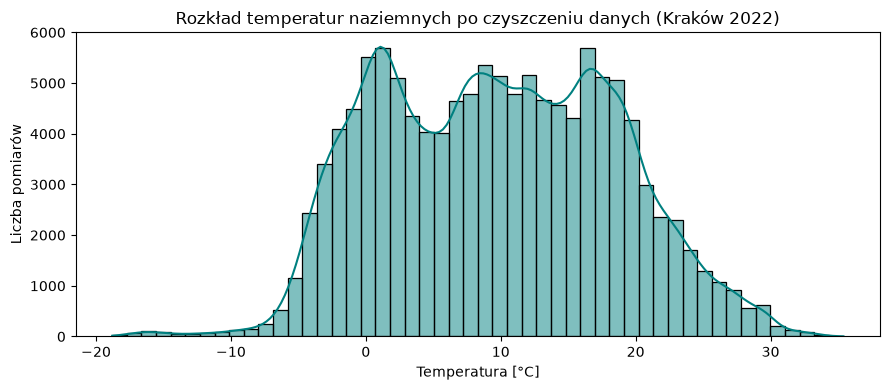

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_cols = [
    'timestamp', 'station', 'data_source', 'lat', 'lon',
    'altitude', 'urban_fraction_500m',
    'sin_hour', 'cos_hour', 'sin_doy', 'cos_doy',
    'temp_era5', 'temp_ground'
]

# Scalenie stacji IMGW i czujników LCS
df_final = pd.concat([df_imgw_final[base_cols], df_lcs_final[base_cols]], ignore_index=True)
df_final['timestamp'] = pd.to_datetime(df_final['timestamp'])
df_final.sort_values(by=['timestamp', 'station'], inplace=True)
df_final.reset_index(drop=True, inplace=True)

# Wyznaczenie pór roku Gumińskiego (analiza fourierowska)
df_final = add_guminski_seasons_harmonic(df_final, timestamp_col='timestamp', temp_col='temp_era5')

# Wyliczenie poprawki rezydualnej, której uczy się model
df_final['delta_temp'] = df_final['temp_ground'] - df_final['temp_era5']
df_final['hour'] = pd.to_datetime(df_final['timestamp']).dt.hour

# Data Quality and Cleaning
print("Sprawdzanie brakujących danych")
missing_report = df_final.isnull().sum()
print(missing_report[missing_report > 0] if missing_report.sum() > 0 else "Brak wartości null!")

# 1. Usunięcie duplikatów dla danej stacji i znacznika czasu
len_before = len(df_final)
df_final = df_final.drop_duplicates(subset=['timestamp', 'station']).copy()
print(f"\nUsunięte duplikaty czasoprzestrzenne: {len_before - len(df_final)}")

# 2. Czyszczenie anomalii fizycznych temperatur (zakres realistyczny dla klimatu Krakowa)
# Usuwamy awarie czujników (np. zawieszenia na -999°C, +80°C itp.)
temp_mask = (df_final['temp_ground'] >= -35.0) & (df_final['temp_ground'] <= 42.0)
df_clean = df_final[temp_mask].copy()
print(f"Odrzucone anomalie temperaturowe: {len(df_final) - len(df_clean)}")

# 3. Kontrola cech przestrzennych
geo_mask = (df_clean['altitude'] > 150) & (df_clean['altitude'] < 600) & \
           (df_clean['urban_fraction_500m'] >= 0.0) & (df_clean['urban_fraction_500m'] <= 1.0)
df_clean = df_clean[geo_mask].copy()

# 4. Usunięcie wierszy z jakimikolwiek pozostałymi brakami
df_clean = df_clean.dropna().reset_index(drop=True)

# 5. Wyznaczenie podzbioru dla roku 2022
df_2022 = df_clean[df_clean['timestamp'].dt.year == 2022].copy().reset_index(drop=True)

print("\n" + "="*50)
print("RAPORT PO OCZYSZCZENIU (ROK 2022):")
print(f"Liczba poprawnych obserwacji: {len(df_2022):,}")
print(f"Liczba monitorowanych stacji: {df_2022['station'].nunique()}")
print(f"Zakres temperatur gruntu: {df_2022['temp_ground'].min():.1f}°C do {df_2022['temp_ground'].max():.1f}°C")
print(f"Zakres wysokości n.p.m.: {df_2022['altitude'].min():.1f} m do {df_2022['altitude'].max():.1f} m")
print("="*50)

# Szybki podgląd rozkładu temperatur po czyszczeniu
plt.figure(figsize=(9, 4))
sns.histplot(df_2022['temp_ground'], bins=50, kde=True, color='teal')
plt.title("Rozkład temperatur naziemnych po czyszczeniu danych (Kraków 2022)")
plt.xlabel("Temperatura [°C]")
plt.ylabel("Liczba pomiarów")
plt.tight_layout()
plt.show()

### Zapis finalnego zbioru danych

In [12]:
# Zapis pełnego zbioru (2000–2025)
df_final.to_csv(PROCESSED_DATA_DIR / "final_dataset.csv", index=False)
df_final.to_parquet(DATASET_FILE, index=False)

# Wyodrębnienie roku 2022 (główny horyzont badawczy ze wspólnym pokryciem stacji i czujników)
df_2022 = df_final[df_final['timestamp'].dt.year == 2022].copy().reset_index(drop=True)
df_2022.dropna(inplace=True)

# Zapis 2022 roku do plików Parquet i CSV
df_2022.to_csv(PROCESSED_DATA_DIR / "final_dataset_2022.csv", index=False)
df_2022.to_parquet(DATASET_2022_PATH, index=False)

print(f"POMYŚLNIE ZAPISANO ZBIÓR DO: {DATASET_2022_PATH}")
print(f"Liczba obserwacji (2022): {len(df_2022):,}")
print(f"Liczba unikalnych stacji: {df_2022['station'].nunique()}")
print("-" * 60)
df_2022.head()

POMYŚLNIE ZAPISANO ZBIÓR DO: C:\inzynierka\climate_downscaling\data\processed\final_dataset_2022.parquet
Liczba obserwacji (2022): 123,694
Liczba unikalnych stacji: 15
------------------------------------------------------------


,timestamp,station,data_source,lat,lon,altitude,urban_fraction_500m,sin_hour,cos_hour,sin_doy,cos_doy,temp_era5,temp_ground,guminski_season,delta_temp,hour
0,2022-01-01,Aleksandrowice,lcs,50.081104,19.764215,242.385681,0.2129,0.0,1.0,0.017202,0.999852,8.454773,8.5,zima,0.045227,0
1,2022-01-01,Biezanow Prokocim,lcs,50.019761,20.052830,208.093094,0.5512,0.0,1.0,0.017202,0.999852,8.989929,9.1,zima,0.110071,0
2,2022-01-01,Debniki,lcs,50.033099,19.895774,214.787842,0.3366,0.0,1.0,0.017202,0.999852,8.778992,8.9,zima,0.121008,0
3,2022-01-01,Grabie,lcs,50.039521,20.134673,197.447372,0.1164,0.0,1.0,0.017202,0.999852,8.989929,9.2,zima,0.210071,0
4,2022-01-01,Krakow-Balice,imgw,50.077700,19.784800,238.000000,0.2566,0.0,1.0,0.017202,0.999852,8.454773,9.2,zima,0.745227,0
